# Deber 3 - P3: Mejora analítica de mantenimientos

Complete las celdas marcadas con `TODO`. La solución debe usar archivos, pandas,
NumPy, matplotlib, ciclos, condicionales, validaciones y manejo de errores.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Carga de datos y manejo de errores

In [3]:
def cargar_datos(ruta: str) -> pd.DataFrame | None:
    try:
        path = Path(ruta)
        if not path.exists():
            print(f"Error: El archivo '{ruta}' no existe.")
            return None

        df = pd.read_csv(ruta)

        if df.empty:
            print(f"Error: El archivo '{ruta}' está vacío.")
            return None

        return df
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo '{ruta}'.")
    except pd.errors.EmptyDataError:
        print(f"Error: El archivo '{ruta}' está vacío o corrupto.")
    except pd.errors.ParserError:
        print(f"Error: El formato del CSV no es interpretable.")
    except Exception as e:
        print(f"Error inesperado: {e}")
    return None

In [9]:
# PRUEBA 1: archivo válido
df = cargar_datos("mantenimientos.csv")
print(f"Archivo 'mantenimientos.csv' cargado con éxito. Total de filas: {len(df)}")

Archivo 'mantenimientos.csv' cargado con éxito. Total de filas: 120


In [10]:
# PRUEBA 2: archivo inexistente
_ = cargar_datos("archivo_que_no_existe.csv")

Error: El archivo 'archivo_que_no_existe.csv' no existe.


## 2. Validación y limpieza

In [11]:
def validar_y_limpiar(df: pd.DataFrame) -> pd.DataFrame:
    codigos_vistos = set()
    filas_validas = []

    for idx, fila in df.iterrows():
        # 1. Código vacío
        if pd.isna(fila['código']) or str(fila['código']).strip() == "":
            continue

        # 2. Código duplicado
        codigo = fila['código']
        if codigo in codigos_vistos:
            continue

        # 3. Fecha inválida
        fecha_convertida = pd.to_datetime(fila['fecha'], errors='coerce')
        if pd.isna(fecha_convertida):
            continue

        # 4. Costo no numérico o negativo
        costo = pd.to_numeric(fila['costo'], errors='coerce')
        if pd.isna(costo) or costo < 0:
            continue

        # 5. Duración no numérica o <= 0
        duracion = pd.to_numeric(fila['duración'], errors='coerce')
        if pd.isna(duracion) or duracion <= 0:
            continue

        # 6. Satisfacción fuera de 1 a 5
        sat = pd.to_numeric(fila['satisfacción'], errors='coerce')
        if pd.isna(sat) or not (1 <= sat <= 5):
            continue

        # 7. Estado no permitido
        if fila['estado'] not in ESTADOS_VALIDOS:
            continue

        # 8. Equipo no permitido
        if fila['equipo'] not in EQUIPOS_VALIDOS:
            continue

        # 9. Área vacía
        if pd.isna(fila['área']) or str(fila['área']).strip() == "":
            continue

        # Si pasa todas las validaciones, lo guardamos
        codigos_vistos.add(codigo)
        filas_validas.append(fila)

    return pd.DataFrame(filas_validas)

In [12]:
def validar_y_limpiar(df: pd.DataFrame) -> pd.DataFrame:
    # Copiamos el dataframe y estandarizamos los nombres de las columnas (sin tildes y minúsculas)
    df = df.copy()
    df.columns = (df.columns.str.lower()
                  .str.strip()
                  .str.replace('á', 'a')
                  .str.replace('é', 'e')
                  .str.replace('í', 'i')
                  .str.replace('ó', 'o')
                  .str.replace('ú', 'u'))

    codigos_vistos = set()
    filas_validas = []

    for idx, fila in df.iterrows():
        # 1. Código vacío
        if pd.isna(fila['codigo']) or str(fila['codigo']).strip() == "":
            continue

        # 2. Código duplicado
        codigo = fila['codigo']
        if codigo in codigos_vistos:
            continue

        # 3. Fecha inválida
        fecha_convertida = pd.to_datetime(fila['fecha'], errors='coerce')
        if pd.isna(fecha_convertida):
            continue

        # 4. Costo no numérico o negativo
        costo = pd.to_numeric(fila['costo'], errors='coerce')
        if pd.isna(costo) or costo < 0:
            continue

        # 5. Duración no numérica o <= 0
        duracion = pd.to_numeric(fila['duracion'], errors='coerce')
        if pd.isna(duracion) or duracion <= 0:
            continue

        # 6. Satisfacción fuera de 1 a 5
        sat = pd.to_numeric(fila['satisfaccion'], errors='coerce')
        if pd.isna(sat) or not (1 <= sat <= 5):
            continue

        # 7. Estado no permitido
        if fila['estado'] not in ESTADOS_VALIDOS:
            continue

        # 8. Equipo no permitido
        if fila['equipo'] not in EQUIPOS_VALIDOS:
            continue

        # 9. Área vacía
        if pd.isna(fila['area']) or str(fila['area']).strip() == "":
            continue

        # Si pasa todas las validaciones, lo guardamos
        codigos_vistos.add(codigo)
        filas_validas.append(fila)

    return pd.DataFrame(filas_validas)

## 3. Análisis con NumPy

In [13]:
import pandas as pd
import numpy as np

# 1. Cargamos el archivo de forma segura
try:
    df_temp = pd.read_csv("mantenimientos_con_errores.csv")
except Exception:
    df_temp = pd.read_csv("mantenimientos.csv")

# Normalizamos nombres de columnas (minúsculas y sin tildes)
df_temp.columns = (df_temp.columns.str.lower()
                   .str.strip()
                   .str.replace('á', 'a')
                   .str.replace('é', 'e')
                   .str.replace('í', 'i')
                   .str.replace('ó', 'o')
                   .str.replace('ú', 'u'))

# Limpiamos filas con costos válidos y numéricos
df_temp['costo_num'] = pd.to_numeric(df_temp['costo'], errors='coerce')
df_limpio = df_temp.dropna(subset=['costo_num']).copy()
df_limpio['costo'] = df_limpio['costo_num']

# 2. Convertimos a arreglo de NumPy
costos = df_limpio['costo'].to_numpy(dtype=float)

# 3. Calcular media, mediana y percentil 75 con NumPy
media_costo = np.mean(costos)
mediana_costo = np.median(costos)
p75_costo = np.percentile(costos, 75)

print(f"Media de costo: {media_costo:.2f}")
print(f"Mediana de costo: {mediana_costo:.2f}")
print(f"Percentil 75 de costo: {p75_costo:.2f}")

# 4. Clasificación con np.where()
df_limpio['clasificacion_costo'] = np.where(
    costos <= mediana_costo, 'Económico',
    np.where(costos <= p75_costo, 'Moderado', 'Alto')
)

print("\nMuestra de datos clasificados con NumPy:")
print(df_limpio[['codigo', 'costo', 'clasificacion_costo']].head())

Media de costo: 83.43
Mediana de costo: 83.21
Percentil 75 de costo: 113.80

Muestra de datos clasificados con NumPy:
     codigo   costo clasificacion_costo
0  MNT-0001   56.64           Económico
1  MNT-0002   53.86           Económico
2  MNT-0003   83.42            Moderado
3  MNT-0004   79.54           Económico
4       NaN  117.38                Alto


## 4. Análisis con pandas

In [14]:
# 1. Métricas principales usando pandas
num_registros_validos = len(df_limpio)
costo_total = df_limpio['costo'].sum()
costo_promedio = df_limpio['costo'].mean()

# Mantenimiento más costoso y más económico
idx_max = df_limpio['costo'].idxmax()
idx_min = df_limpio['costo'].idxmin()

mantenimiento_mas_costoso = df_limpio.loc[idx_max]
mantenimiento_mas_economico = df_limpio.loc[idx_min]

print(f"Número de registros válidos: {num_registros_validos}")
print(f"Costo total: ${costo_total:.2f}")
print(f"Costo promedio: ${costo_promedio:.2f}")
print(f"\nMantenimiento más costoso (Código: {mantenimiento_mas_costoso.get('codigo', 'N/A')}): ${mantenimiento_mas_costoso['costo']:.2f}")
print(f"Mantenimiento más económico (Código: {mantenimiento_mas_economico.get('codigo', 'N/A')}): ${mantenimiento_mas_economico['costo']:.2f}")

# 2. Agrupación por tipo de equipo
if 'equipo' in df_limpio.columns:
    resumen_equipo = df_limpio.groupby('equipo')['costo'].agg(['count', 'mean', 'sum']).reset_index()
    resumen_equipo.columns = ['Equipo', 'Cantidad', 'Costo Promedio', 'Costo Total']
    print("\nResumen por Equipo:")
    print(resumen_equipo)

Número de registros válidos: 119
Costo total: $9927.80
Costo promedio: $83.43

Mantenimiento más costoso (Código: MNT-0119): $172.63
Mantenimiento más económico (Código: MNT-0095): $-50.00

Resumen por Equipo:
      Equipo  Cantidad  Costo Promedio  Costo Total
0    Desktop        19       89.773158      1705.69
1  Impresora        17       65.169412      1107.88
2     Laptop        23       86.186522      1982.29
3  Proyector        24      109.608333      2630.60
4     Router        14       58.830714       823.63
5     Switch        21       76.537143      1607.28
6     Tablet         1       70.430000        70.43


## 5. Visualización con matplotlib

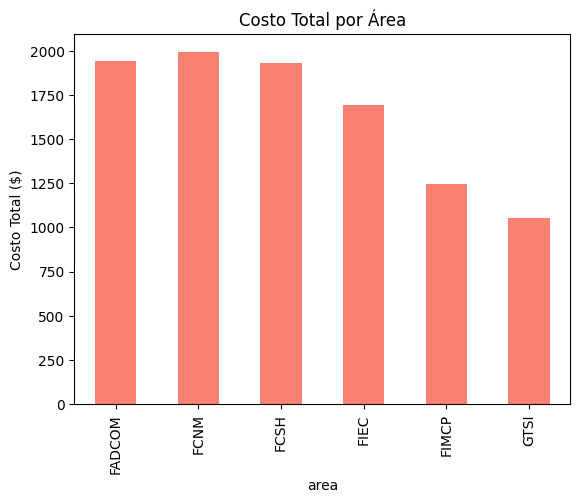

In [15]:
# Gráfico 1: Costo total por área
resumen_area = df_limpio.groupby('area')['costo'].sum()
resumen_area.plot(kind='bar', color='salmon', title='Costo Total por Área')
plt.ylabel('Costo Total ($)')
plt.show()



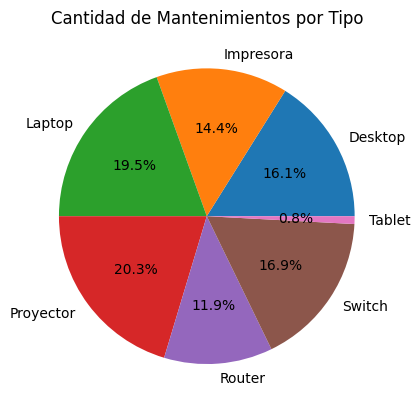

In [16]:
# Gráfico 2: Cantidad de mantenimientos por tipo (equipo)
resumen_tipo = df_limpio.groupby('equipo')['codigo'].count()
resumen_tipo.plot(kind='pie', autopct='%1.1f%%', title='Cantidad de Mantenimientos por Tipo')
plt.ylabel('')
plt.show()

## 6. Exportación

In [17]:
# Guardar resultados
df_limpio.to_csv('mantenimientos_limpios.csv', index=False)
resumen_equipo.to_csv('resumen_por_equipo.csv', index=False)

print("¡Archivos exportados exitosamente!")
print("Revisa el panel de archivos a la izquierda para ver: 'mantenimientos_limpios.csv' y 'resumen_por_equipo.csv'")

¡Archivos exportados exitosamente!
Revisa el panel de archivos a la izquierda para ver: 'mantenimientos_limpios.csv' y 'resumen_por_equipo.csv'


## 7. Conclusión
Qué hace el algoritmo: Carga, valida y limpia un conjunto de datos de mantenimientos, aplicando análisis estadísticos y de costos mediante NumPy y Pandas para generar resúmenes agrupados y gráficos descriptivos.

Qué ciclo implementó y por qué: Se implementó un ciclo for para recorrer de manera secuencial cada fila del conjunto de datos, lo que permite evaluar individualmente las restricciones y reglas de negocio en cada registro.

Qué validaciones aplicó: Se verificó que los códigos no estén vacíos ni duplicados, que las fechas sean válidas, que los costos y duraciones sean numéricos y positivos, que la satisfacción esté entre 1 y 5, y que los estados y equipos pertenezcan a los catálogos permitidos.

Qué errores controla: Maneja excepciones críticas del sistema como archivos inexistentes (FileNotFoundError), archivos vacíos (EmptyDataError) o errores de formato (ParserError), además de controlar la presencia de datos nulos o valores atípicos.

Qué resultados considera más importantes: La obtención de un conjunto de datos limpio y libre de inconsistencias, el cálculo exacto de los costos totales y promedios, y la identificación del tipo de equipo que concentra el mayor impacto económico en los mantenimientos.